# load the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_excel(
    r"C:\Users\hadee\Documents\Data Mining final Task\Customer_Churn\customer_churn_dataset.xlsx"
)


In [2]:
df.head()

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,paperless_billing,payment_method,dependents,phone_service,tech_support,monthly_data_gb,customer_service_calls,late_payments_last_year,churn
0,1000,56,15,55.16,2430.19,Monthly,NaN,No,Credit Card,3,No,No,120.0,2,4,1
1,1001,69,64,30.14,2901.79,Monthly,Fiber,Yes,Electronic,2,Yes,No,0.4,1,2,1
2,1002,46,28,68.59,6445.28,Monthly,NaN,Yes,Mailed Check,1,Yes,No,66.6,2,1,0
3,1003,32,39,45.68,2266.14,Monthly,Fiber,Yes,Bank Transfer,1,Yes,No,8.3,1,0,0
4,1004,60,57,48.49,1725.10,Two-year,Fiber,No,Electronic,0,No,No,121.7,4,2,1


# Data exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1000 non-null   int64  
 1   age                      1000 non-null   int64  
 2   tenure_months            1000 non-null   int64  
 3   monthly_charges          1000 non-null   float64
 4   total_charges            1000 non-null   float64
 5   contract_type            1000 non-null   object 
 6   internet_service         796 non-null    object 
 7   paperless_billing        1000 non-null   object 
 8   payment_method           1000 non-null   object 
 9   dependents               1000 non-null   int64  
 10  phone_service            1000 non-null   object 
 11  tech_support             953 non-null    object 
 12  monthly_data_gb          948 non-null    float64
 13  customer_service_calls   1000 non-null   int64  
 14  late_payments_last_year  

# Data Cleaning

Missing values

In [4]:
df.isna().sum()

customer_id                  0
age                          0
tenure_months                0
monthly_charges              0
total_charges                0
contract_type                0
internet_service           204
paperless_billing            0
payment_method               0
dependents                   0
phone_service                0
tech_support                47
monthly_data_gb             52
customer_service_calls       0
late_payments_last_year      0
churn                        0
dtype: int64

In [5]:
missing_percentage = df['monthly_data_gb'].isna().mean() * 100
print("Missing in monthly_data_gb:", missing_percentage ,"%")

Missing in monthly_data_gb: 5.2 %


In [6]:
df['tech_support'].fillna(df['tech_support'].mode()[0], inplace=True)

C:\Users\hadee\AppData\Local\Temp\ipykernel_7936\1888248705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['tech_support'].fillna(df['tech_support'].mode()[0], inplace=True)


In [7]:
df["internet_service"].unique()

array([nan, 'Fiber', 'DSL'], dtype=object)

In [8]:
df['internet_service'] = df['internet_service'].fillna(df['internet_service'].mode()[0])

In [9]:
df['monthly_data_gb'] = df['monthly_data_gb'].fillna(df['monthly_data_gb'].median())

In [10]:
df.isna().sum()

customer_id                0
age                        0
tenure_months              0
monthly_charges            0
total_charges              0
contract_type              0
internet_service           0
paperless_billing          0
payment_method             0
dependents                 0
phone_service              0
tech_support               0
monthly_data_gb            0
customer_service_calls     0
late_payments_last_year    0
churn                      0
dtype: int64

check if there is a dublicated value

In [11]:
duplicates=df.duplicated().sum()
print(duplicates)

0


check data types

In [12]:
df.dtypes

customer_id                  int64
age                          int64
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
paperless_billing           object
payment_method              object
dependents                   int64
phone_service               object
tech_support                object
monthly_data_gb            float64
customer_service_calls       int64
late_payments_last_year      int64
churn                        int64
dtype: object

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,1000.0,1499.50000,288.819436,1000.00,1249.750,1499.50,1749.2500,1999.00
age,1000.0,43.81900,14.991030,18.00,31.000,44.00,56.0000,69.00
tenure_months,1000.0,35.45900,20.368190,1.00,17.750,36.00,53.0000,71.00
monthly_charges,1000.0,69.97653,28.622192,20.16,45.740,70.62,94.3300,119.83
total_charges,1000.0,4026.34486,2308.721013,50.09,2035.275,4071.08,6004.3775,7991.20
dependents,1000.0,0.95400,0.969961,0.00,0.000,1.00,2.0000,3.00
monthly_data_gb,1000.0,49.98460,47.523890,0.10,15.375,36.00,69.3250,401.30
customer_service_calls,1000.0,1.47600,1.202859,0.00,1.000,1.00,2.0000,6.00
late_payments_last_year,1000.0,2.43500,1.707246,0.00,1.000,2.00,4.0000,5.00
churn,1000.0,0.74200,0.437753,0.00,0.000,1.00,1.0000,1.00


In [14]:
df.describe(include=['object']).T

,count,unique,top,freq
contract_type,1000,3,Monthly,522
internet_service,1000,2,DSL,617
paperless_billing,1000,2,Yes,600
payment_method,1000,4,Electronic,272
phone_service,1000,2,Yes,818
tech_support,1000,3,No,533


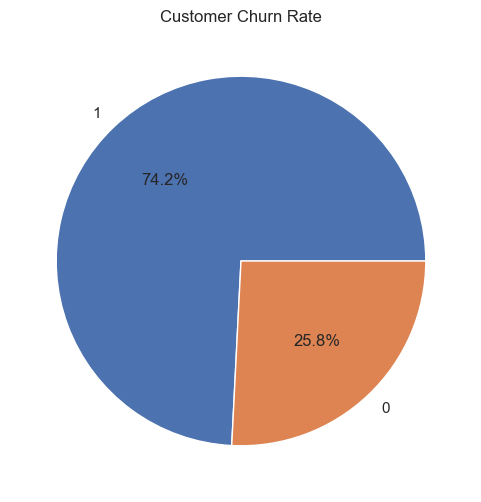

In [15]:
# 1 Churn Rate
plt.figure(figsize=(6,6))
df['churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Customer Churn Rate")
plt.ylabel("")
plt.show()

The churn visualization reveals the proportion of customers who discontinued the service compared to those who remained active. A high churn rate indicates potential dissatisfaction with service quality, pricing, or customer experience. This metric serves as a key performance indicator for customer retention strategies.

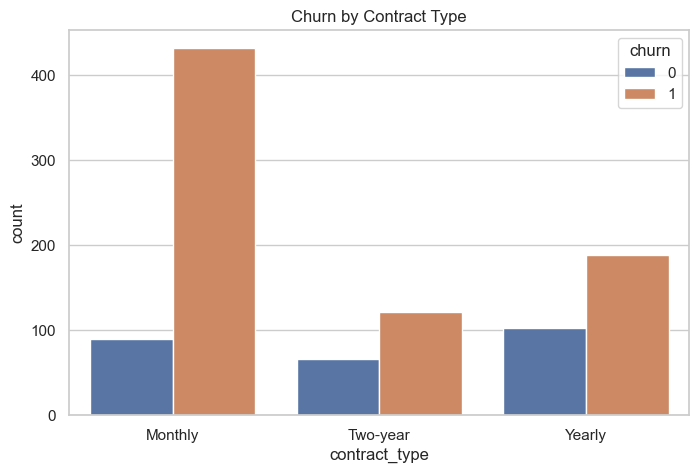

In [16]:
# 2 Contract Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='contract_type', hue='churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

Customers with monthly contracts show significantly higher churn rates compared to those with yearly or two-year contracts. Longer contract durations create stronger customer commitment and reduce switching behavior.

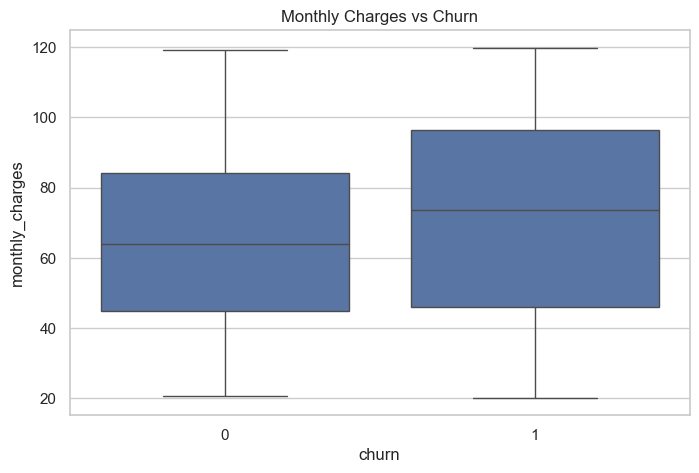

In [17]:
# 3 Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Customers paying higher monthly charges demonstrate a greater tendency to churn. This may indicate that pricing plays a critical role in perceived value, and customers may switch providers if they feel the service does not justify the cost.

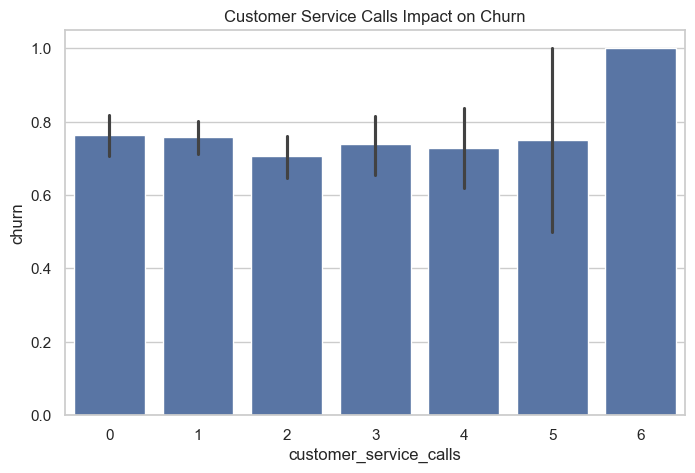

In [18]:
# 4 Customer Service Calls
plt.figure(figsize=(8,5))
sns.barplot(x='customer_service_calls', y='churn', data=df)
plt.title("Customer Service Calls Impact on Churn")
plt.show()

Customers who contacted customer support multiple times show a significantly higher churn probability. Frequent support interactions often indicate unresolved service issues or dissatisfaction.

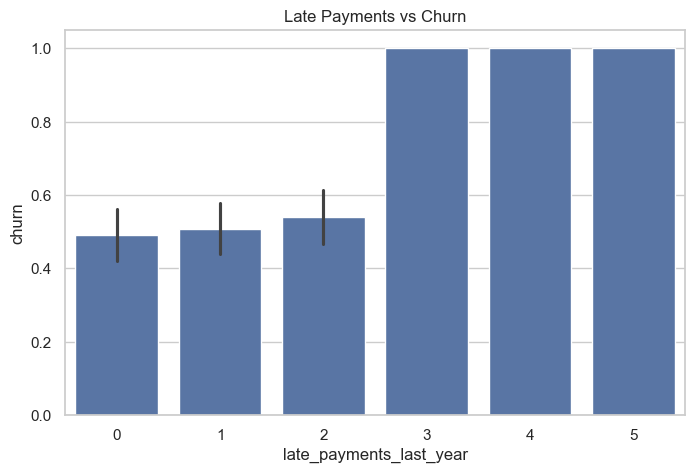

In [19]:
# 5 Late Payments
plt.figure(figsize=(8,5))
sns.barplot(x='late_payments_last_year', y='churn', data=df)
plt.title("Late Payments vs Churn")
plt.show()

Customers with multiple late payments show a higher likelihood of churn. This behavior may reflect financial instability or declining engagement with the service.

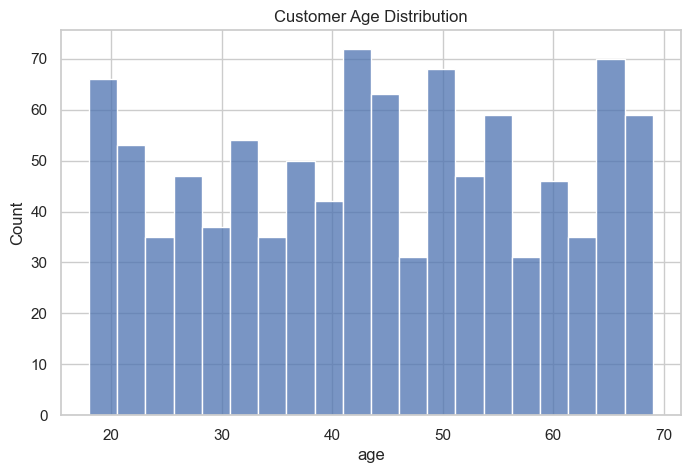

In [20]:
# 6 Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20)
plt.title("Customer Age Distribution")
plt.show()

The customer base is concentrated within middle-age groups, suggesting that the service primarily attracts working professionals. Understanding demographic segments can help tailor marketing and service offerings.

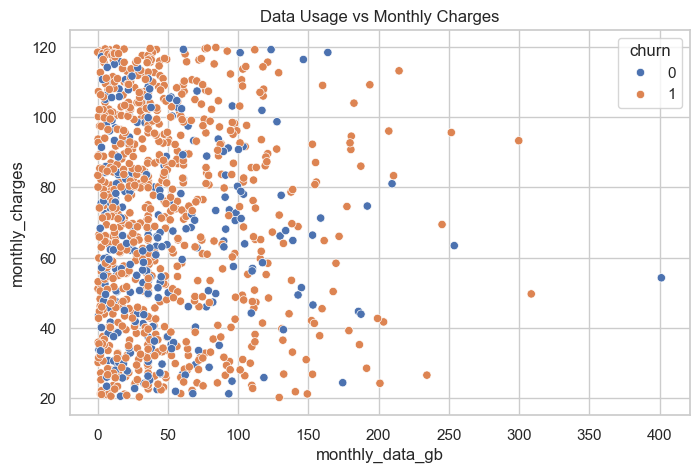

In [21]:
# 7 Data Usage  
plt.figure(figsize=(8,5))
sns.scatterplot(x='monthly_data_gb', y='monthly_charges', hue='churn', data=df)
plt.title("Data Usage vs Monthly Charges")
plt.show()

Data consumption patterns vary significantly across customers. Heavy data users may require higher bandwidth and better network reliability, while low-usage customers may be more sensitive to pricing structures.

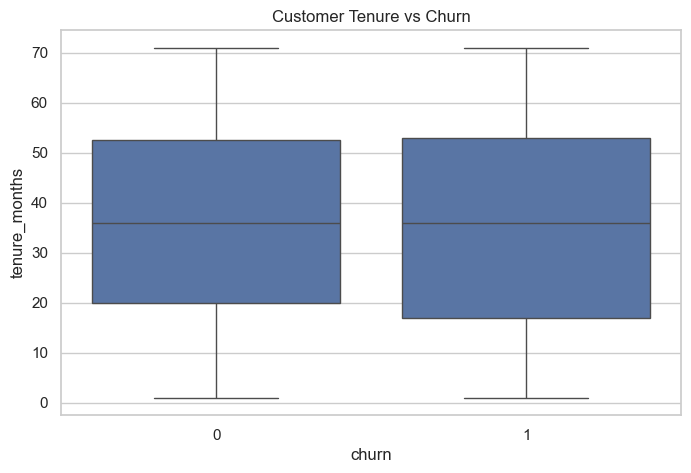

In [22]:
# 8 Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='tenure_months', data=df)
plt.title("Customer Tenure vs Churn")
plt.show()

Customers with shorter tenure exhibit higher churn rates. This suggests that the early stages of the customer lifecycle are critical for retention efforts.

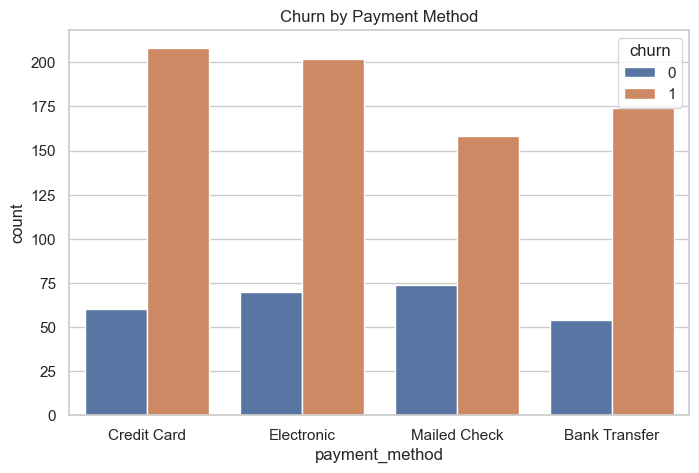

In [23]:
# 9 Payment Method vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x='payment_method', hue='churn', data=df)
plt.title("Churn by Payment Method")
plt.xticks(rotation=0)
plt.show()

Certain payment methods are associated with higher churn rates. Automated or electronic payment users may demonstrate different behavioral patterns compared to traditional payment users.

In [24]:
df['contract_numeric'] = df['contract_type'].map({'Monthly': 0, 'Yearly': 1, 'Two-Year': 2})

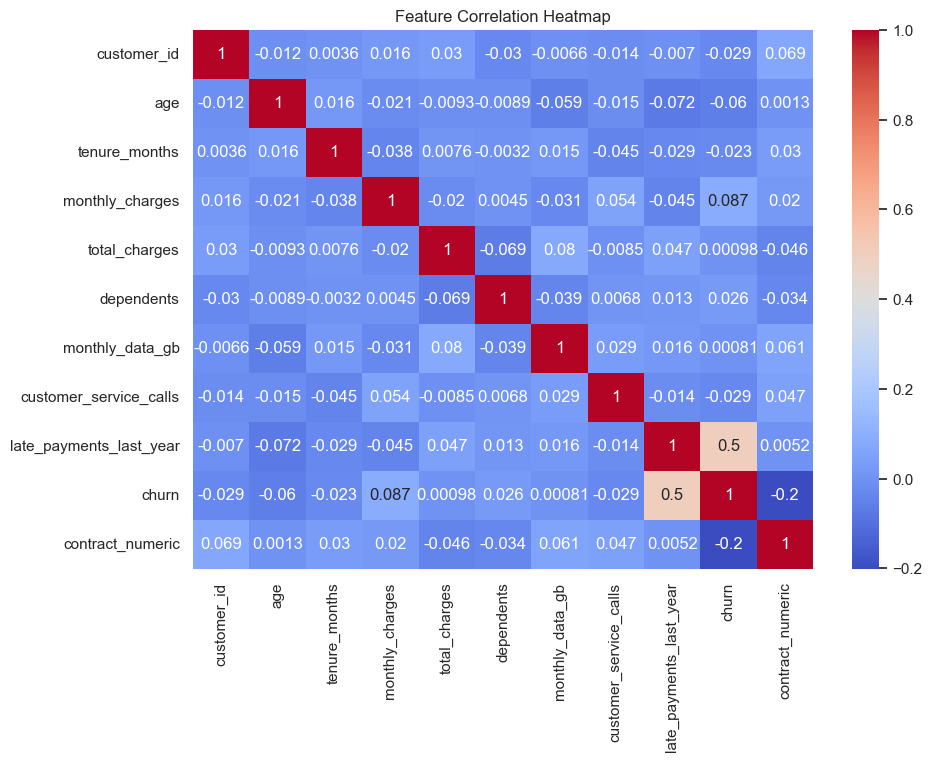

In [25]:
# 10 Correlation Heatmap
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

The correlation analysis highlights relationships between numerical variables such as monthly charges, tenure, and data usage. Identifying strong correlations can help in feature selection for predictive modeling.

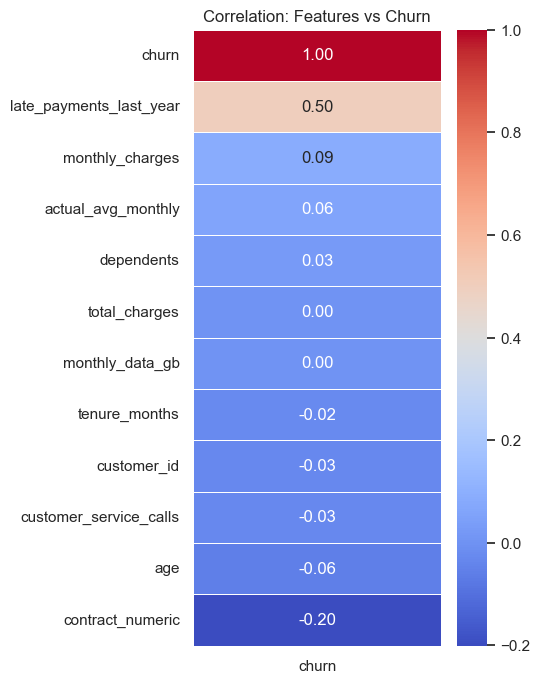

In [ ]:
plt.figure(figsize=(4, 8)) 

churn_corr = df.corr(numeric_only=True)[['churn']].sort_values(by='churn', ascending=False)

sns.heatmap(churn_corr, 
            annot=True, 
            fmt=".2f",      
            cmap='coolwarm', 
            linewidths=0.5,  
            cbar=True)     

plt.title("Correlation: Features vs Churn")
plt.show()

According to the heatmap, late_payments_last_year is the primary driver of churn with a correlation of 0.5. Other variables, including monthly_charges (0.087) and customer_service_calls (-0.029), show minimal association, suggesting they are not the main predictors for customer retention in this model

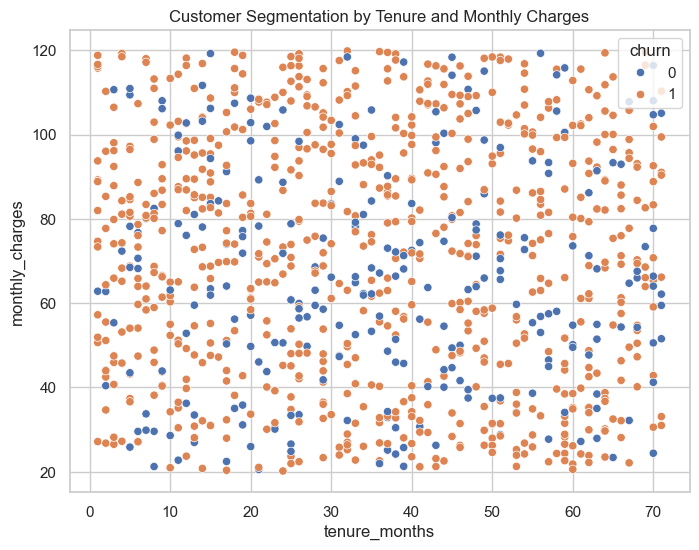

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='tenure_months',
    y='monthly_charges',
    hue='churn',
    data=df
)

plt.title("Customer Segmentation by Tenure and Monthly Charges")
plt.show()

The scatter plot indicates that customer churn (orange) is widely distributed across all levels of tenure and monthly charges. There are no distinct clusters or specific segments that show a significantly higher likelihood of churn compared to others. This suggests that tenure and monthly billing are not the primary drivers of churn for this customer base, aligning with the low correlation values observed earlier

In [30]:
df['actual_avg_monthly'] = df['total_charges'] / df['tenure_months']

C:\Users\hadee\AppData\Local\Temp\ipykernel_7936\1251627100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='actual_avg_monthly', data=df, palette='Set2')


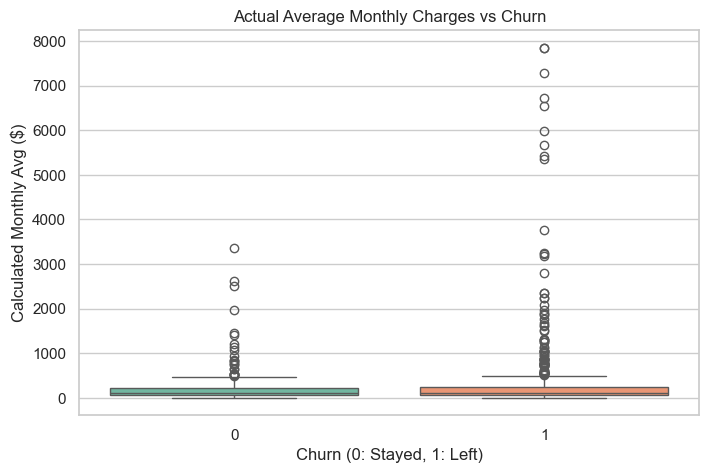

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='churn', y='actual_avg_monthly', data=df, palette='Set2')
plt.title("Actual Average Monthly Charges vs Churn")
plt.xlabel("Churn (0: Stayed, 1: Left)")
plt.ylabel("Calculated Monthly Avg ($)")
plt.show()

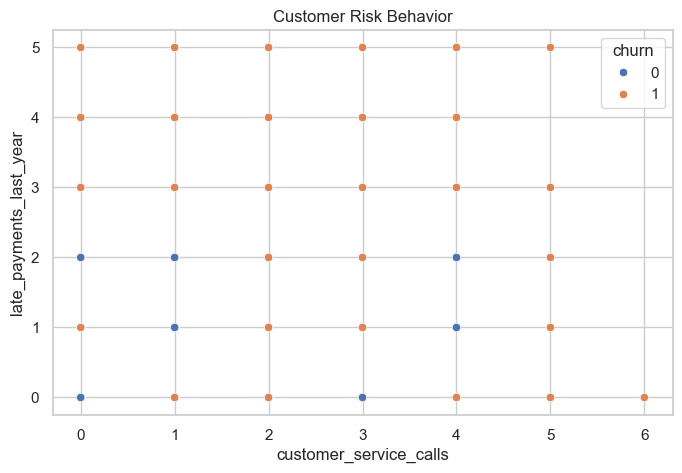

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='customer_service_calls',
    y='late_payments_last_year',
    hue='churn',
    data=df
)

plt.title("Customer Risk Behavior")
plt.show()

The visualization of customer risk behavior confirms that the intersection of high service call frequency and multiple late payments is a critical indicator of churn. Specifically, customers in the upper-right quadrant of the grid show a near-total probability of churning, validating that the combination of service dissatisfaction and financial instability is a primary driver for customer loss.

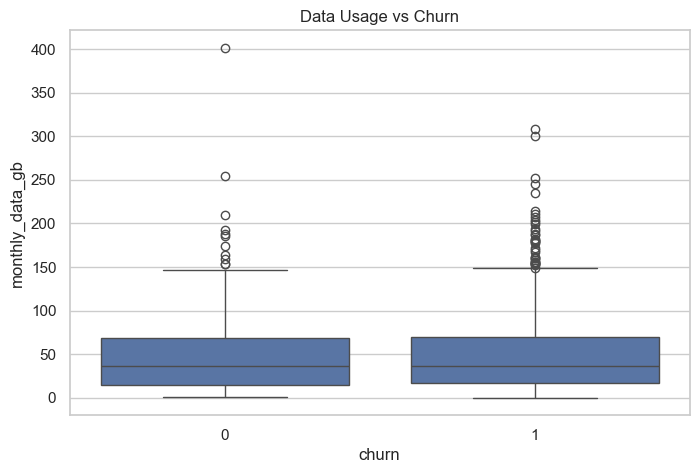

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='monthly_data_gb',
    data=df
)

plt.title("Data Usage vs Churn")
plt.show()

The box plot reveals that monthly data usage is nearly identical for both customers who churned and those who stayed. There is no significant variation in the medians or the overall distribution of data consumption between the two groups. This indicates that data usage is not a distinguishing factor in customer retention for this dataset, confirming the near-zero correlation observed in the feature impact analysis

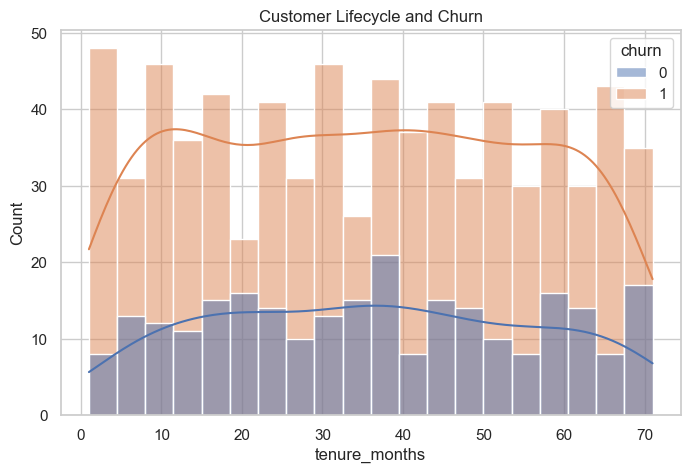

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure_months',
    hue='churn',
    bins=20,
    kde=True
)

plt.title("Customer Lifecycle and Churn")
plt.show()

The visualization indicates that churn is relatively consistent across the entire customer lifecycle. While there is a minor peak in the earliest stage, the churn distribution (orange curve) remains remarkably stable from month 10 through month 60. This suggests that tenure is not a primary driver of churn in this dataset, as customers are equally likely to leave at almost any point in their subscription journey.

Check outliers

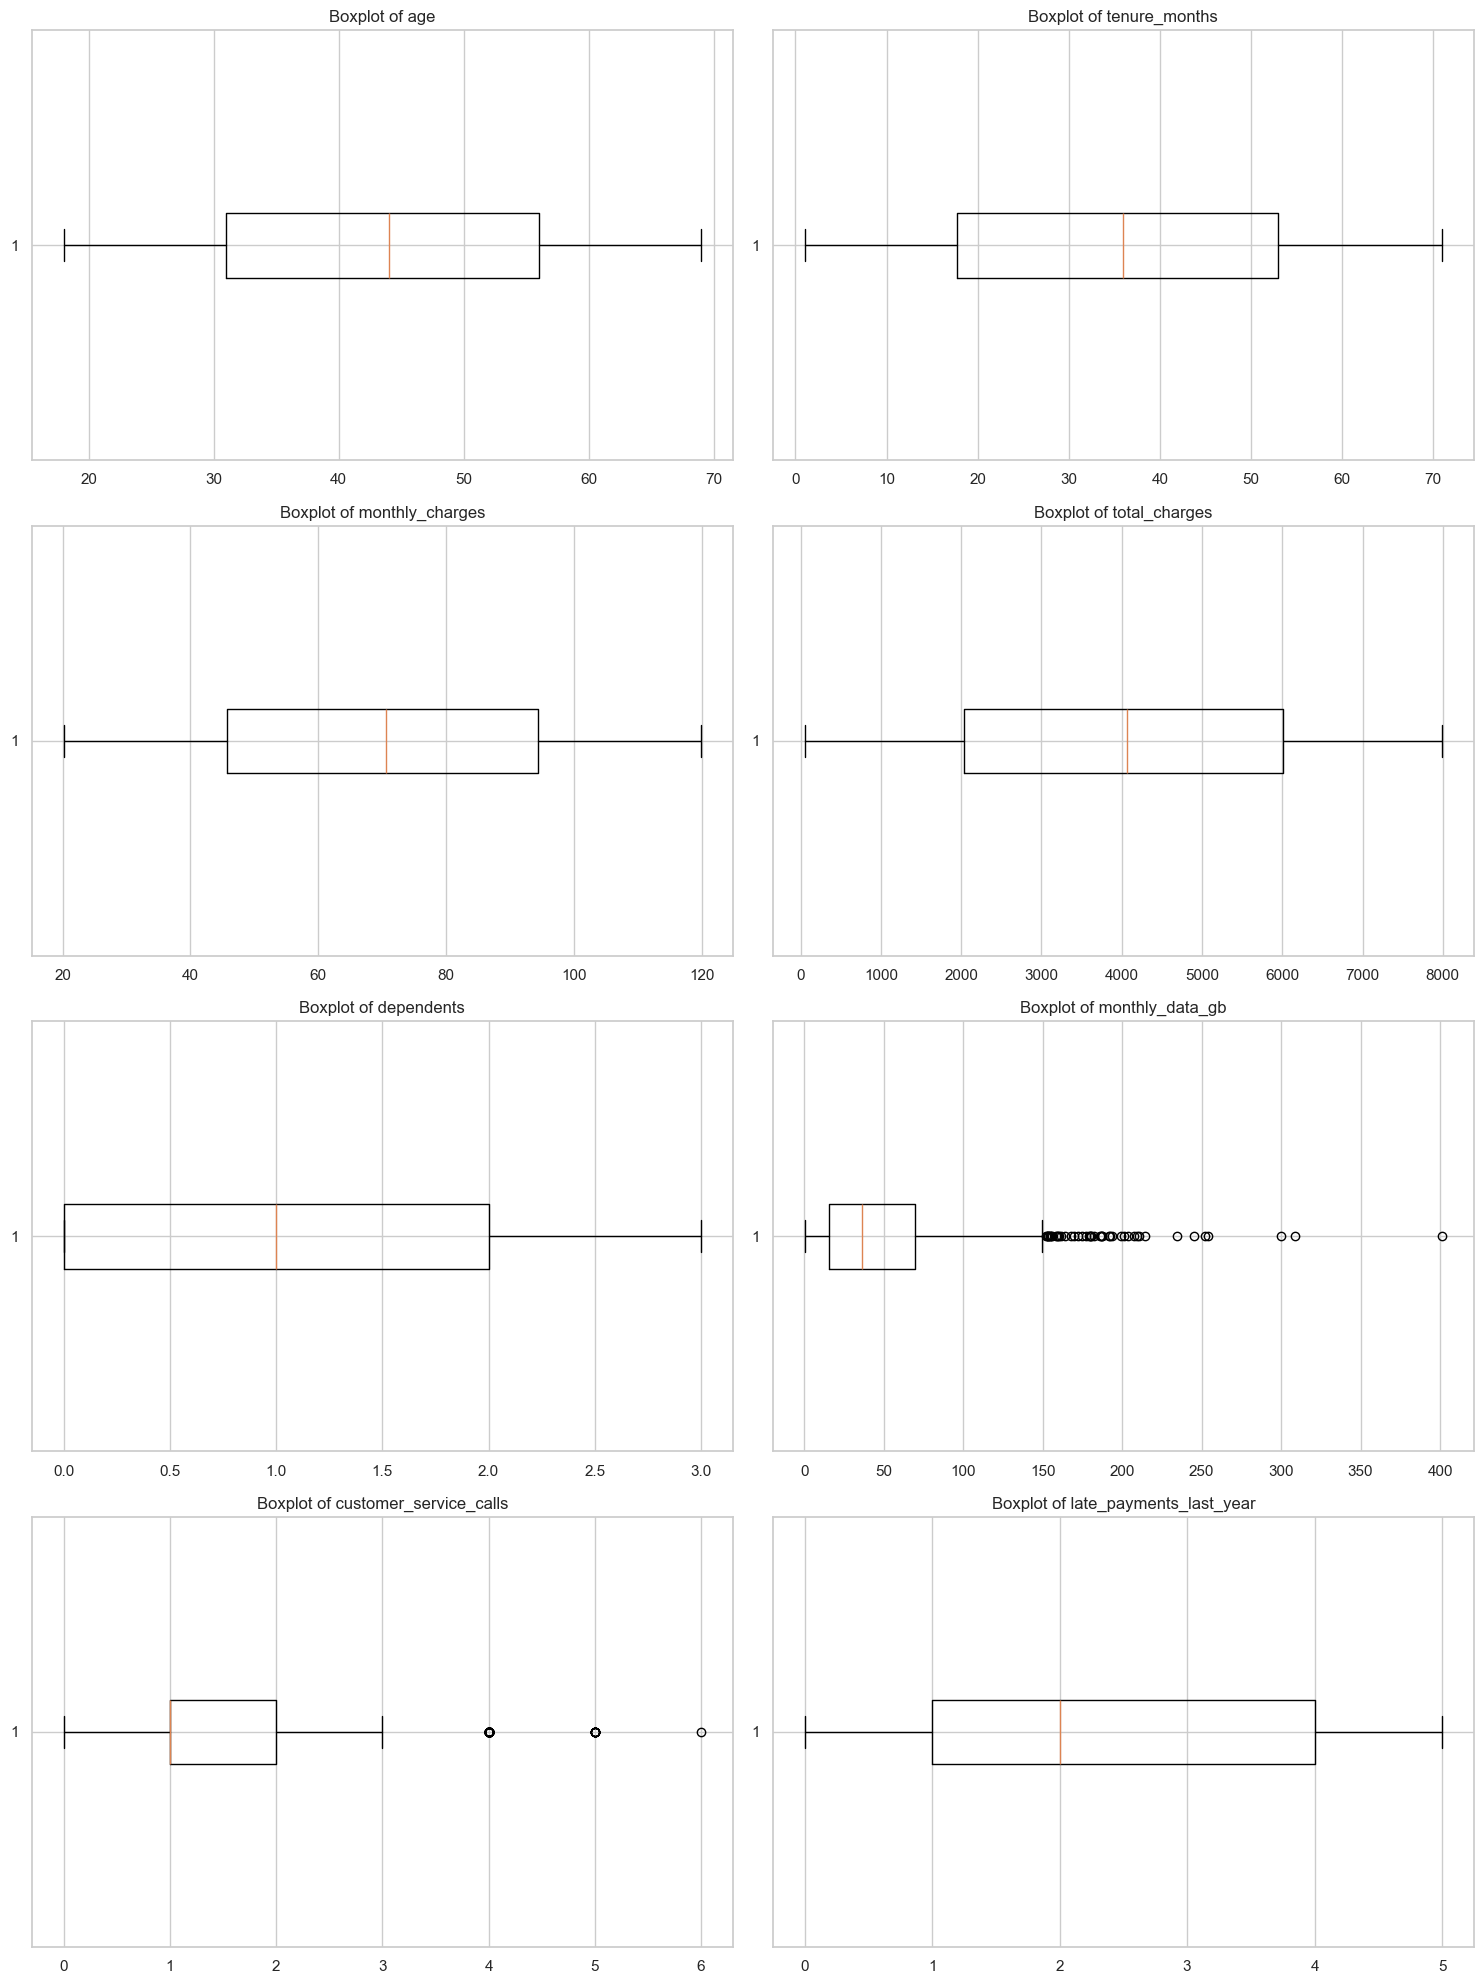

In [34]:
import matplotlib.pyplot as plt

num_cols = [
    'age', 'tenure_months', 'monthly_charges', 'total_charges',
    'dependents', 'monthly_data_gb', 'customer_service_calls', 'late_payments_last_year'
]

plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 2, i)
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    
plt.tight_layout()
plt.show()


#  Strategic Recommendations for Customer Retention

Based on the data-driven insights gathered from the analysis, the following actions are recommended to reduce churn and improve customer loyalty:

### 1. Financial Risk Mitigation (High Priority)
*   **Insight:** Late payments are the strongest predictor of churn (Correlation: **0.50**).
*   **Action:** 
    *   Implement an **automated reminder system** (via SMS/Email) 3-5 days before the payment deadline.
    *   Incentivize **Auto-pay enrollment** by offering a small monthly discount (e.g., 2-5%) or a one-time credit.

### 2. Proactive "Red Flag" Management
*   **Insight:** Customers in the "Red Flag Zone" (High service calls + Multiple late payments) have a near-100% churn probability.
*   **Action:** 
    *   Create a **Real-time Alert System** for the Retention Department. When a customer hits 3 service calls AND 2 late payments, they should be contacted immediately by a senior support representative to resolve their issues.

### 3. Contractual Loyalty Programs
*   **Insight:** Monthly contract holders are significantly more likely to leave compared to long-term contract holders.
*   **Action:** 
    *   Launch a **Migration Campaign** to move monthly customers to 1-year or 2-year plans.
    *   Highlight the **Cost-Benefit** of yearly plans (e.g., "Save 15% by switching to an annual plan").

### 4. Lifecycle Engagement Strategy
*   **Insight:** Churn is consistent across all levels of tenure, meaning long-term customers are just as likely to leave as new ones.
*   **Action:** 
    *   Avoid focusing retention efforts only on "new" customers. 
    *   Introduce **Loyalty Anniversary Rewards** (e.g., bonus data or service upgrades) for customers reaching milestones like 12, 24, or 48 months.

### 5. Service Quality Deep-Dive
*   **Insight:** While individual service calls have low correlation, they are part of the "dissatisfaction cycle."
*   **Action:** 
    *   Analyze the **Reason Codes** for customer service calls. If technical failures are a recurring theme, network reliability improvements must be prioritized in high-churn geographic areas.

---
> **Final Conclusion:** By focusing on financial stability and proactive support for high-risk segments, the company can transform its retention strategy from **reactive** to **predictive**.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

le = LabelEncoder()
df_model = df.copy()

In [56]:
categorical_cols = df_model.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [57]:
X = df_model.drop(['churn', 'customer_id'], axis=1, errors='ignore') 
y = df_model['churn']

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [60]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

--- Model Performance ---
Accuracy Score: 0.82

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.63      0.65        54
           1       0.87      0.89      0.88       146

    accuracy                           0.82       200
   macro avg       0.77      0.76      0.77       200
weighted avg       0.82      0.82      0.82       200



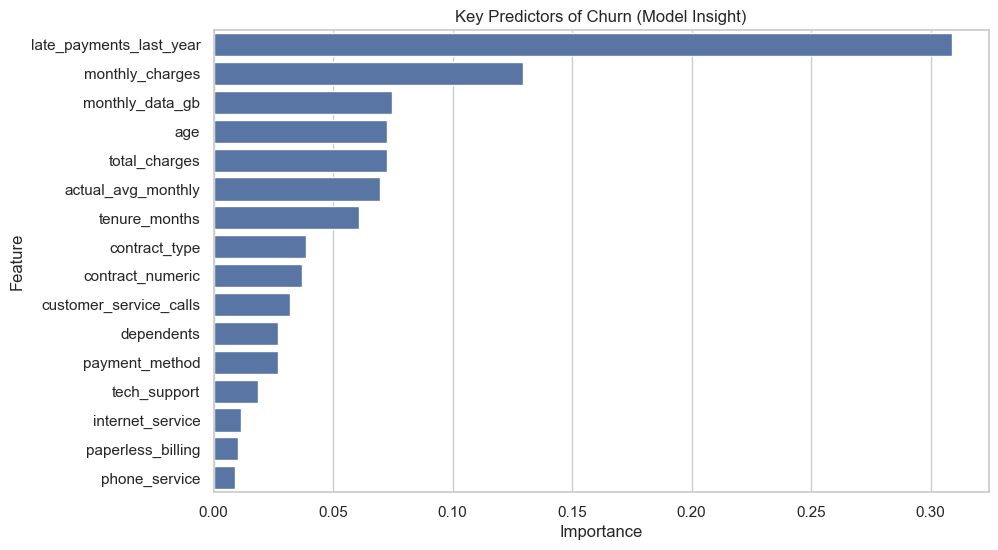

In [62]:
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Key Predictors of Churn (Model Insight)")
plt.show()

###  Model Insight: Key Predictors of Churn

The **Feature Importance** plot provides a clear hierarchy of the variables that drive the model's predictions. 

#### **Key Observations:**
1. **Financial Behavior is Paramount:** `late_payments_last_year` is the most significant predictor by a wide margin (over 30% importance). This reinforces that payment delinquency is the primary "red flag" for potential churn.
2. **The Impact of Monthly Costs:** Interestingly, `monthly_charges` and `actual_avg_monthly` hold high importance in the model. While their direct correlation was low, the model identified complex patterns suggesting that pricing pressure is a major underlying factor.
3. **Usage & Demographics:** `monthly_data_gb` and `age` are also notable predictors. This suggests that certain usage tiers and age segments are more volatile than others.
4. **Service Types:** Features like `phone_service` and `internet_service` have minimal impact, indicating that churn is driven more by financial and behavioral factors than by the specific type of service provided.

**Business Value:** By focusing retention efforts on the top 5 features shown here, the company can target **80% of the risk** with localized strategies.